In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load all tables

dtypes = {
    'household_key': 'int32',
    'BASKET_ID': 'int64',
    'DAY': 'int16',
    'PRODUCT_ID': 'int32',
    'QUANTITY': 'int16',
    'SALES_VALUE': 'float32',
    'STORE_ID': 'int16',
    'RETAIL_DISC': 'float32',
    'TRANS_TIME': 'int16',
    'WEEK_NO': 'int16',
    'COUPON_DISC': 'float32',
    'COUPON_MATCH_DISC': 'float32'
}

transactions = pd.read_csv(
    r'..\data\dunnhumby_The-Complete-Journey\transaction_data.csv',
    dtype=dtypes
)
campaigns = pd.read_csv(r'..\data\dunnhumby_The-Complete-Journey\campaign_table.csv')
campaign_desc = pd.read_csv(r'..\data\dunnhumby_The-Complete-Journey\campaign_desc.csv')
coupon_redempt = pd.read_csv(r'..\data\dunnhumby_The-Complete-Journey\coupon_redempt.csv')
product = pd.read_csv(r'..\data\dunnhumby_The-Complete-Journey\product.csv')
hh_demo = pd.read_csv(r'..\data\dunnhumby_The-Complete-Journey\hh_demographic.csv')

In [5]:
# Dataset overview
print("Households:", transactions['household_key'].nunique())
print("Weeks:", transactions['WEEK_NO'].min(), "-", transactions['WEEK_NO'].max())
print("Total transactions:", len(transactions))
print("\nCampaign types:\n", campaigns['DESCRIPTION'].value_counts())
print("\nTotal redemptions:", len(coupon_redempt))
print("Households redeemed:", coupon_redempt['household_key'].nunique())
print("Households in campaigns:", campaigns['household_key'].nunique())

Households: 2500
Weeks: 1 - 102
Total transactions: 2595732

Campaign types:
 DESCRIPTION
TypeA    3979
TypeB    2655
TypeC     574
Name: count, dtype: int64

Total redemptions: 2318
Households redeemed: 434
Households in campaigns: 1584


In [6]:
# Redemption rate
hh_in_campaigns = campaigns['household_key'].nunique()
hh_redeemed = coupon_redempt['household_key'].nunique()
print(f"Redemption rate: {hh_redeemed/hh_in_campaigns:.2%}")

Redemption rate: 27.40%


<>:7: SyntaxWarning: invalid escape sequence '\o'
<>:7: SyntaxWarning: invalid escape sequence '\o'
C:\Users\Nida Ali Khan\AppData\Local\Temp\ipykernel_27280\1109129639.py:7: SyntaxWarning: invalid escape sequence '\o'
  plt.savefig('..\outputs/weekly_spend_dist.png')


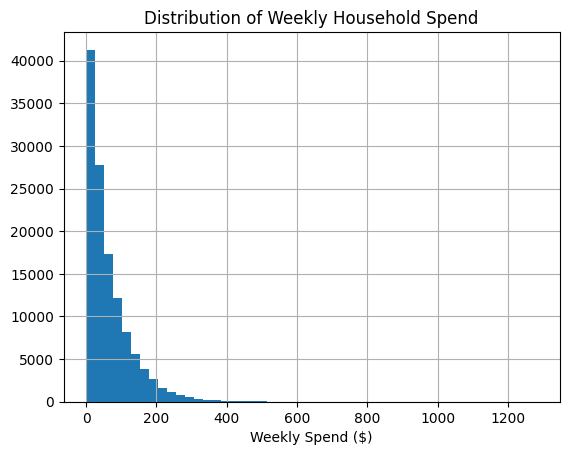

In [9]:
# Spending distribution
weekly_spend = transactions.groupby(
    ['household_key','WEEK_NO'])['SALES_VALUE'].sum().reset_index()
weekly_spend['SALES_VALUE'].hist(bins=50)
plt.title('Distribution of Weekly Household Spend')
plt.xlabel('Weekly Spend ($)')
plt.savefig('..\outputs/weekly_spend_dist.png')

In [12]:
# Temporal ordering of campaigns
campaign_desc_sorted = campaign_desc.sort_values('START_DAY')
print(campaign_desc_sorted[['CAMPAIGN','DESCRIPTION','START_DAY','END_DAY']])

    CAMPAIGN DESCRIPTION  START_DAY  END_DAY
29        26       TypeA        224      264
28        27       TypeC        237      300
27        28       TypeB        259      320
26        29       TypeB        281      334
25        30       TypeA        323      369
23         1       TypeB        346      383
24         2       TypeB        351      383
20         3       TypeC        356      412
22         4       TypeB        372      404
21         5       TypeB        377      411
19         6       TypeC        393      425
18         7       TypeB        398      432
17         8       TypeA        412      460
16         9       TypeB        435      467
15        10       TypeB        463      495
13        11       TypeB        477      523
14        12       TypeB        477      509
12        13       TypeA        504      551
10        14       TypeC        531      596
1         15       TypeC        547      708
11        16       TypeB        561      593
9         